In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import anndata as ad
import tensorflow as tf
import wandb
import keras
import crested
import pickle 

analysis_dir = "/staging/leuven/stg_00090/ASA/analysis/"
%matplotlib inline

# consensus peaks
peaks = {
    "CC": f"{analysis_dir}/2024_T2T_ATAC_analysis/CC/out/consensus_peak_calling/CC_CT2_consensus_regions.bed",
    "SN": f"{analysis_dir}/2024_T2T_ATAC_analysis/SN/out/consensus_peak_calling/SN_CT2_consensus_regions.bed"
}

# bigwigs
bigwigs = {
    "CC": f"{analysis_dir}/2024_T2T_ATAC_analysis/CC/out/consensus_peak_calling/CISTOPIC_2_final_annot_bw_2025_DL/",
    "SN": f"{analysis_dir}/2024_T2T_ATAC_analysis/SN/out/consensus_peak_calling/CISTOPIC_2_final_annot_bw/"
}

2025-06-16 12:44:31.992735: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-16 12:44:36.691101: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750070677.506193 2975493 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750070677.771271 2975493 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1750070680.219418 2975493 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [2]:
# Set the genome
genome = crested.Genome(
    "/staging/leuven/res_00001/genomes/homo_sapiens/CHM13v2_maskedY_rCRS/fasta/chm13v2.0_maskedY_rCRS.fa", 
    "/staging/leuven/res_00001/genomes/homo_sapiens/CHM13v2_maskedY_rCRS/fasta/chm13v2.0_maskedY_rCRS.chrom.sizes"
)

crested.register_genome(
    genome
)

2025-06-16T12:45:02.153616+0200 INFO Genome chm13v2.0_maskedY_rCRS registered.


In [20]:
tf.config.list_physical_devices()

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'),
 PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [5]:
#!nvidia-smi

## CC model

In [21]:
bigwigs_folder = bigwigs["CC"]
regions_file = peaks["CC"]

In [4]:
# V1 - predict counts (unused - for cut site bigwigs)
# adata_cc = crested.import_bigwigs(
#     bigwigs_folder=bigwigs_folder,
#     regions_file=regions_file,
#     target_region_width=1000,  # optionally, use a different width than the consensus regions file (500bp) for the .X values calculation
#     target="count",  # or "max", "mean", "logcount" --> what we will be predicting
# )


2025-06-03T22:25:37.700602+0200 INFO Extracting values from 22 bigWig files...


In [22]:
# V2 - predict mean
adata_cc = crested.import_bigwigs(
    bigwigs_folder=bigwigs_folder,
    regions_file=regions_file,
    target_region_width=1000,  # optionally, use a different width than the consensus regions file (500bp) for the .X values calculation
    target="mean",  # or "max", "mean", "logcount" --> what we will be predicting
)

2025-06-06T14:26:30.565747+0200 INFO Extracting values from 21 bigWig files...


In [23]:
# Choose the chromosomes for the validation and test sets (same as deepTopic Regression)
crested.pp.train_val_test_split(
    adata_cc, strategy="chr", val_chroms=["chr22", "chr2"], test_chroms=["chr4", "chr9"]
)

print(adata_cc.var["split"].value_counts())
adata_cc.var.head(3)

split
train    1359226
test      171158
val       171049
Name: count, dtype: int64


,chr,start,end,split
region,,,,
chr1:209476-209976,chr1,209476,209976,train
chr1:226193-226693,chr1,226193,226693,train
chr1:232617-233117,chr1,232617,233117,train


In [24]:
crested.pp.change_regions_width(
    adata_cc,
    2114,
)  # change the adata width of the regions to 2114bp

2025-06-06T14:42:12.442124+0200 WARNING Region chrM:15181-17295 with coordinates chrM:15181-17295 is out of bounds for chromosome chrM. Removing region.
2025-06-06T14:42:12.476499+0200 WARNING Region chrM:-277-1837 with coordinates chrM:-277-1837 is out of bounds for chromosome chrM. Removing region.


In [25]:
# Normalize peaks
crested.pp.normalize_peaks(
    adata_cc, top_k_percent=0.03
)  # The top_k_percent parameters can be tuned based on potential bias towards cell types. If some weights are overcompensating too much, consider increasing the top_k_percent. Default is 0.01

2025-06-06T14:42:41.102310+0200 INFO Filtering on top k Gini scores...
2025-06-06T14:42:58.205365+0200 INFO Added normalization weights to adata.obsm['weights']...


,chr,start,end,split
region,,,,
chr6:144818933-144821047,chr6,144818933,144821047,train
chr3:159315406-159317520,chr3,159315406,159317520,train
chr1:439740-441854,chr1,439740,441854,train
chr1:532310-534424,chr1,532310,534424,train
chr1:544340-546454,chr1,544340,546454,train
...,...,...,...,...
chr12:124868029-124870143,chr12,124868029,124870143,train
chr12:124997778-124999892,chr12,124997778,124999892,train
chr10:73165518-73167632,chr10,73165518,73167632,train


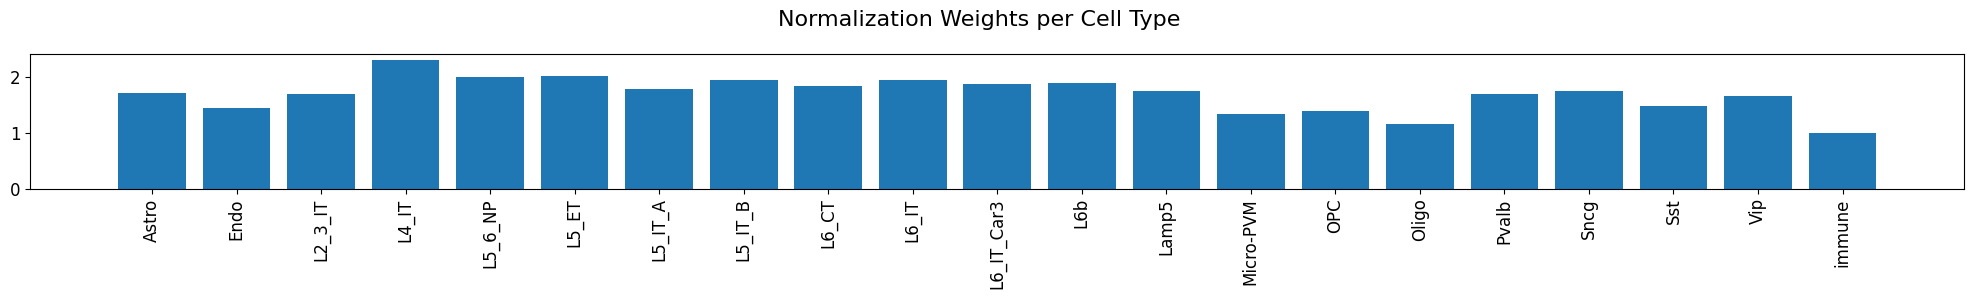

In [26]:
crested.pl.bar.normalization_weights(
    adata_cc, title="Normalization Weights per Cell Type", x_label_rotation=90
)

In [27]:
outdir = f"{analysis_dir}/analysis_Olga/3_T2T_analysis/2_CREsted_models/peak_regression/"
os.makedirs(outdir, exist_ok=True)

# Save the adata object - for predicting count
#adata_cc.write_h5ad(f"{outdir}/adata_cc_norm.h5ad")

# Save the adata object - for predicting count
adata_cc.write_h5ad(f"{outdir}/adata_cc_mean_norm.h5ad")

In [14]:
# adata_path = f"{analysis_dir}/analysis_Olga/3_T2T_analysis/2_CREsted_models/peak_regression/adata_cc_norm.h5ad"
# adata_cc = ad.read_h5ad(adata_path)

In [28]:
# select specific regions for fine-tuning

crested.pp.filter_regions_on_specificity(
    adata_cc, gini_std_threshold=1.0
)  # All regions with a Gini index 1 std above the mean across all regions will be kept

adata_cc

2025-06-06T14:43:26.830600+0200 INFO After specificity filtering, kept 274805 out of 1701431 regions.


AnnData object with n_obs × n_vars = 21 × 274805
    obs: 'file_path'
    var: 'chr', 'start', 'end', 'split'
    obsm: 'weights'

In [29]:
# save specific regions
# adata_cc.write_h5ad(f"{outdir}/adata_cc_norm_specific.h5ad")

adata_cc.write_h5ad(f"{outdir}/adata_cc_mean_norm_specific.h5ad")

In [3]:
adata_path = f"{analysis_dir}/analysis_Olga/3_T2T_analysis/2_CREsted_models/peak_regression/adata_cc_mean_norm_specific.h5ad"
adata_cc = ad.read_h5ad(adata_path)

In [4]:
adata_cc.obs_names 

Index(['Astro', 'Endo', 'L2_3_IT', 'L4_IT', 'L5_6_NP', 'L5_ET', 'L5_IT_A',
       'L5_IT_B', 'L6_CT', 'L6_IT', 'L6_IT_Car3', 'L6b', 'Lamp5', 'Micro-PVM',
       'OPC', 'Oligo', 'Pvalb', 'Sncg', 'Sst', 'Vip', 'immune'],
      dtype='object')

# SN model

In [9]:
bigwigs_folder = bigwigs["SN"]
regions_file = peaks["SN"]

In [10]:
adata_sn = crested.import_bigwigs(
    bigwigs_folder=bigwigs_folder,
    regions_file=regions_file,
    target_region_width=1000,  # optionally, use a different width than the consensus regions file (500bp) for the .X values calculation
    target="mean",  # "count" - for cut sites bigwigs
)


2025-06-06T12:38:22.041031+0200 INFO Extracting values from 9 bigWig files...


In [11]:
# Choose the chromosomes for the validation and test sets (same as deepTopic Regression)
crested.pp.train_val_test_split(
    adata_sn, strategy="chr", val_chroms=["chr22", "chr2"], test_chroms=["chr4", "chr9"]
)

print(adata_sn.var["split"].value_counts())
adata_sn.var.head(3)

split
train    977259
val      122058
test     116692
Name: count, dtype: int64


,chr,start,end,split
region,,,,
chr1:226222-226722,chr1,226222,226722,train
chr1:233582-234082,chr1,233582,234082,train
chr1:236099-236599,chr1,236099,236599,train


In [12]:
crested.pp.change_regions_width(
    adata_sn,
    2114,
)  # change the adata width of the regions to 2114bp

2025-06-06T12:40:44.502201+0200 WARNING Region chrM:15183-17297 with coordinates chrM:15183-17297 is out of bounds for chromosome chrM. Removing region.
2025-06-06T12:40:44.528547+0200 WARNING Region chrM:14508-16622 with coordinates chrM:14508-16622 is out of bounds for chromosome chrM. Removing region.
2025-06-06T12:40:44.541615+0200 WARNING Region chrM:-497-1617 with coordinates chrM:-497-1617 is out of bounds for chromosome chrM. Removing region.


In [13]:
# Normalize peaks
crested.pp.normalize_peaks(
    adata_sn, top_k_percent=0.03
)  # The top_k_percent parameters can be tuned based on potential bias towards cell types. If some weights are overcompensating too much, consider increasing the top_k_percent. Default is 0.01

2025-06-06T12:41:05.201351+0200 INFO Filtering on top k Gini scores...
2025-06-06T12:41:10.783510+0200 INFO Added normalization weights to adata.obsm['weights']...


,chr,start,end,split
region,,,,
chr17:19595218-19597332,chr17,19595218,19597332,train
chr22:23563930-23566044,chr22,23563930,23566044,val
chr22:23567142-23569256,chr22,23567142,23569256,val
chr22:23595901-23598015,chr22,23595901,23598015,val
chr22:23599306-23601420,chr22,23599306,23601420,val
...,...,...,...,...
chr22:22364831-22366945,chr22,22364831,22366945,val
chr22:22365390-22367504,chr22,22365390,22367504,val
chr22:22395305-22397419,chr22,22395305,22397419,val


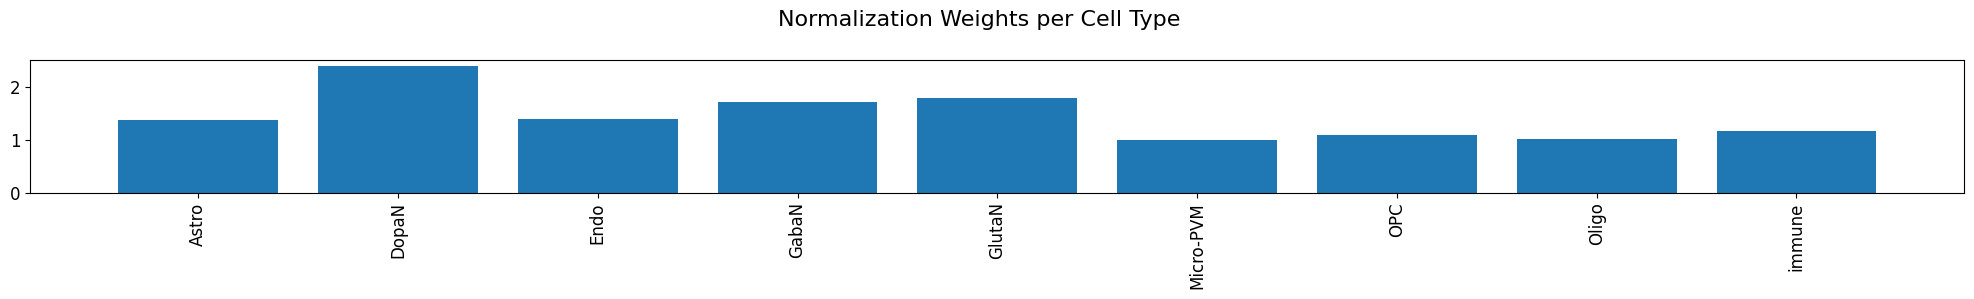

In [14]:
crested.pl.bar.normalization_weights(
    adata_sn, title="Normalization Weights per Cell Type", x_label_rotation=90
)

In [15]:
outdir = f"{analysis_dir}/analysis_Olga/3_T2T_analysis/2_CREsted_models/peak_regression/"
os.makedirs(outdir, exist_ok=True)

# Save the adata object
adata_sn.write_h5ad(f"{outdir}/adata_sn_mean_norm.h5ad") # adata_sn_norm.h5ad was used for counts adata - should be used only with cut sites bw

In [16]:
# select specific regions for fine-tuning

crested.pp.filter_regions_on_specificity(
    adata_sn, gini_std_threshold=1.0
)  # All regions with a Gini index 1 std above the mean across all regions will be kept

adata_sn

2025-06-06T12:41:32.216587+0200 INFO After specificity filtering, kept 194202 out of 1216006 regions.


AnnData object with n_obs × n_vars = 9 × 194202
    obs: 'file_path'
    var: 'chr', 'start', 'end', 'split'
    obsm: 'weights'

In [17]:
# save specific regions
adata_sn.write_h5ad(f"{outdir}/adata_sn_mean_norm_specific.h5ad")